# Weeks 3 & 4 Exercises



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Activity 1: 3.01

The first step of this activity is to load the data. Head(10) can be used to confirm that the data was loaded correctly, it shows the first 10 records. Shape can also be used to see the number of records that the file has. 

In [2]:
housing = pd.read_csv("/Users/rosienavarro/Data_Science/Boston_housing.csv")

housing.head(10)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


In [3]:
housing.shape

(506, 14)

There are a total of 14 variables and 506 records.

For the next part, Chas, Nox, B, and Lsat will be excluded from the dataset. In order to do this, all of the other variables will be named in the new dataset. There should be a total of 10 variables. 

To make sure that the correct variables were chosen, the last 7 records will be displayed (using tail). 

In [4]:
house = housing[['CRIM', 'ZN', 'INDUS', 'RM', 'AGE', 'DIS', 'RAD','TAX', 'PTRATIO', 'PRICE']]

house.tail(7)

,CRIM,ZN,INDUS,RM,AGE,DIS,RAD,TAX,PTRATIO,PRICE
499,0.17783,0.0,9.69,5.569,73.5,2.3999,6,391,19.2,17.5
500,0.22438,0.0,9.69,6.027,79.7,2.4982,6,391,19.2,16.8
501,0.06263,0.0,11.93,6.593,69.1,2.4786,1,273,21.0,22.4
502,0.04527,0.0,11.93,6.120,76.7,2.2875,1,273,21.0,20.6
503,0.06076,0.0,11.93,6.976,91.0,2.1675,1,273,21.0,23.9
504,0.10959,0.0,11.93,6.794,89.3,2.3889,1,273,21.0,22.0
505,0.04741,0.0,11.93,6.030,80.8,2.5050,1,273,21.0,11.9


A histogram will be created for all of the variables. Instead of manually creating each one, for loop can be used to create a histogram for all of the variables (there should be a total of 10 histograms). 

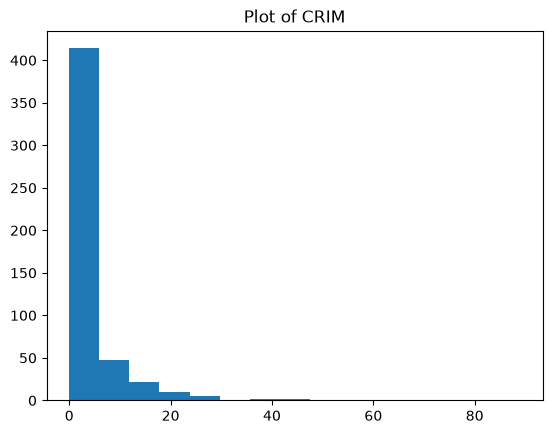

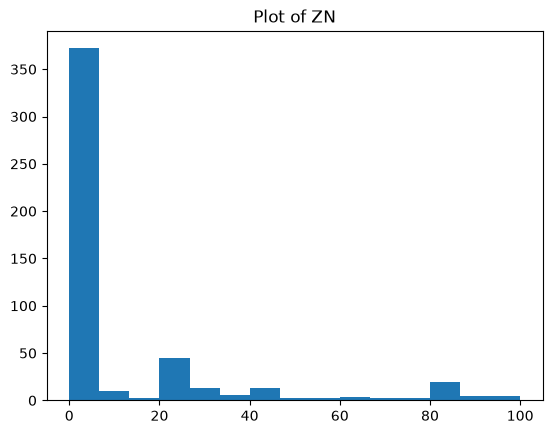

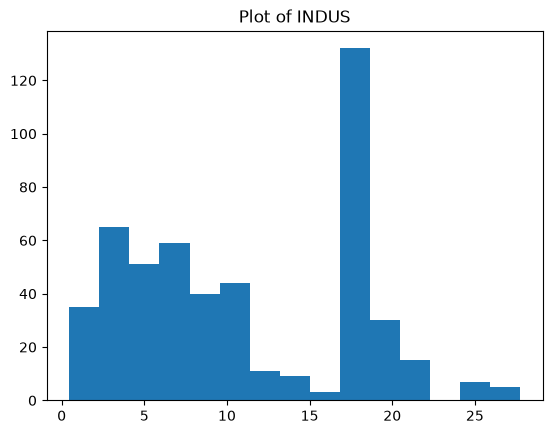

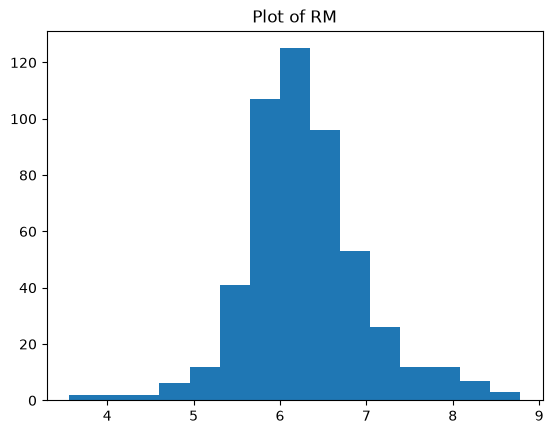

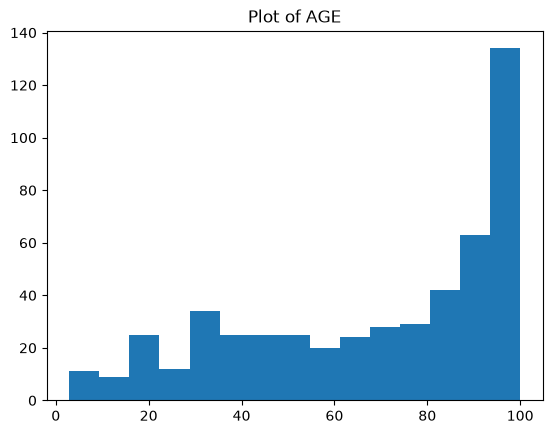

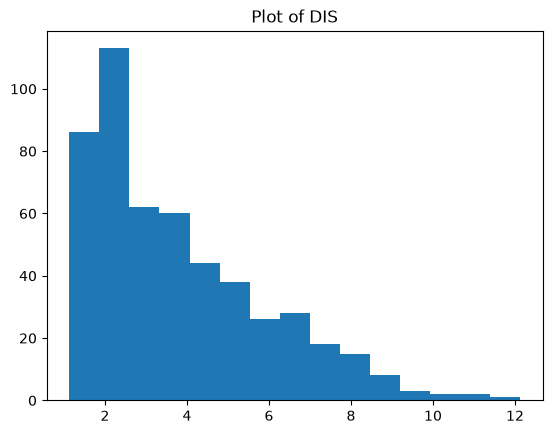

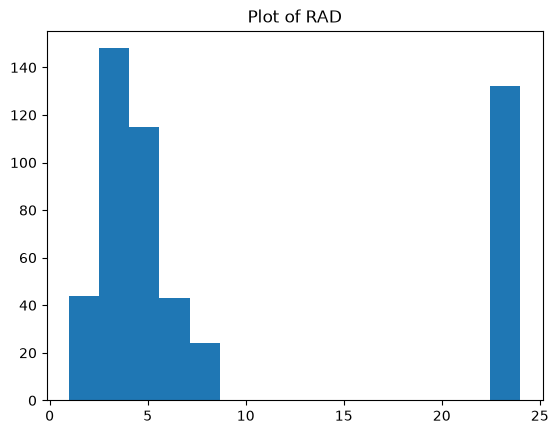

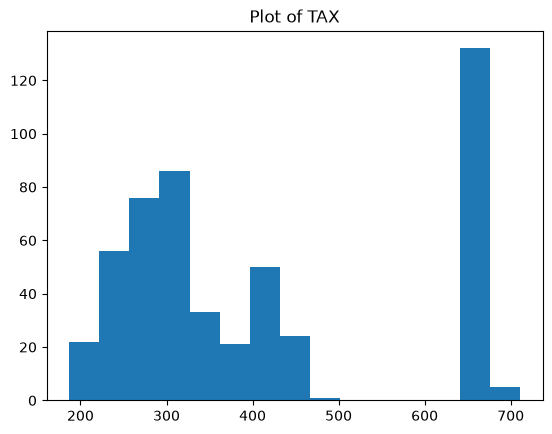

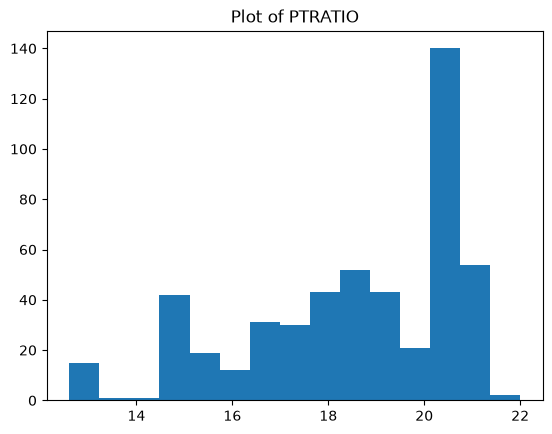

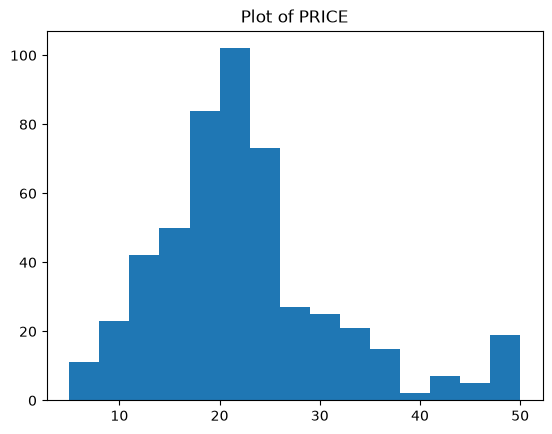

In [5]:
for c in house.columns:
    plt.title("Plot of " +c)
    plt.hist(house[c], bins=15)
    plt.show()

There is a total of 10 different histograms, each one having its own distribution and range. 

An additional graph will be created. A scatter plot to see the relationship between crime rate and price. 

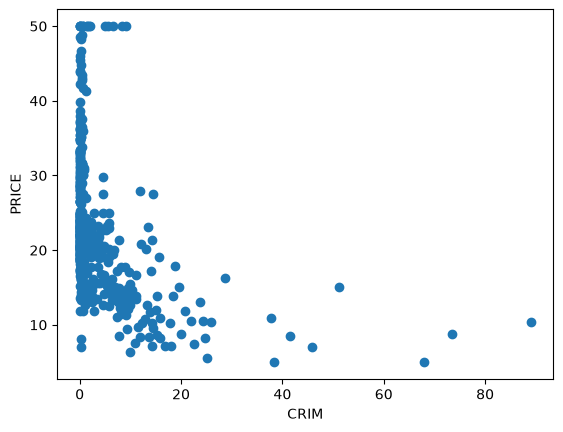

In [6]:
plt.scatter(house['CRIM'], house['PRICE'])
plt.xlabel("CRIM")
plt.ylabel("PRICE")
plt.show()

The scatter plot does not look like there is a negative or positive correlation most of the points are found near 0 (CRIM). To make sure that there is not a correlation, the data needs to be scaled. This can be done by doing log10 on crime. 

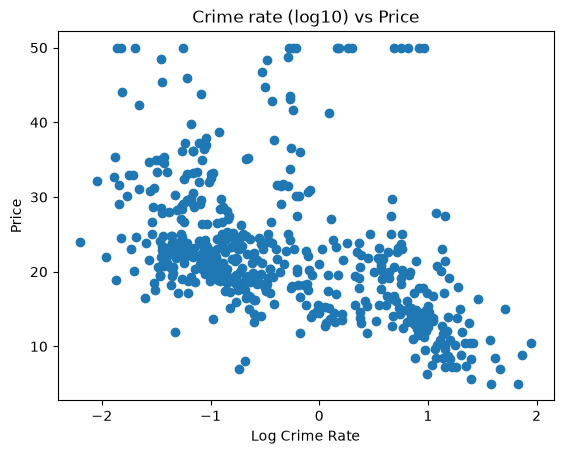

In [14]:
plt.scatter(np.log10(house['CRIM']), house['PRICE'])
plt.title("Crime rate (log10) vs Price")
plt.ylabel("Price")
plt.xlabel("Log Crime Rate")
plt.show()

Once the data has been scaled, it is easier to see the correlation between Crime rate and Price. There seems to be a moderate strong negative correlationship between the two variables. 

The next steps is to find the mean room, median age, mean distance, and the percentage of houses below $20K. 

In [7]:
house['RM'].mean()

np.float64(6.284634387351779)

In [8]:
house['AGE'].median()

np.float64(77.5)

In [9]:
house['DIS'].mean()

np.float64(3.795042687747036)

In [10]:
low = house['PRICE']<20
print(low)

0      False
1      False
2      False
3      False
4      False
       ...  
501    False
502    False
503    False
504    False
505     True
Name: PRICE, Length: 506, dtype: bool


In [19]:
low.mean()

percent = low.mean()*100
print(percent)

41.50197628458498


## Activity 2: 4.01:

This acitivity will use the Adult incomde data set (csv and txt file). to find outliers. 

First step is to load the data and make sure that the data was loaded correctly. 

In [12]:
UCI = pd.read_csv("/Users/rosienavarro/Data_Science/adult_income_data.csv")

UCI.head()

,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,Male,2174,0,40,United-States,<=50K
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,Female,0,0,40,United-States,<=50K


Using the txt file each line will be read to find the variables in the dataset. A list will be created (names) to store the variable names. Will loop line by line until it reaches the end. 

In [13]:
names = []

with open('/Users/rosienavarro/Data_Science/adult_income_names.txt', 'r') as f:
    for line in f:
        var = line.split(":")[0].strip()
        if var:
            names.append(var)
print(names[:10])

['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'sex', 'capital-gain']


There are a total of 10 variables. 

The next step is to create an additional variable Income that can be added to the dataset, this can be done using append.  
Data can be loaded again to make sure that Income was added to the dataset. 

In [14]:
names.append('Income')

In [15]:
UCI = pd.read_csv("/Users/rosienavarro/Data_Science/adult_income_data.csv", names=names)
UCI.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,sex,capital-gain,capital-loss,hours-per-week,native-country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Female,0,0,40,Cuba,<=50K


Now that income has been added to the dataset, we need to see if there are any missing values, this can be done using null sum. There will be a list of the variables, if there are any missing values, then a number will appear next to the variable. 

In [16]:
UCI.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
Income            0
dtype: int64

There are not missing values. A dataframe will be created with Age, education, and occupation. It will only show the first 5 rows of the data. 

In [17]:
subset = UCI[['age', 'education', 'occupation']]
subset.head()

,age,education,occupation
0,39,Bachelors,Adm-clerical
1,50,Bachelors,Exec-managerial
2,38,HS-grad,Handlers-cleaners
3,53,11th,Handlers-cleaners
4,28,Bachelors,Prof-specialty


With the new subset, the only variable that is numeric is age. A histogram will be made with 20 bins. 

<Axes: >

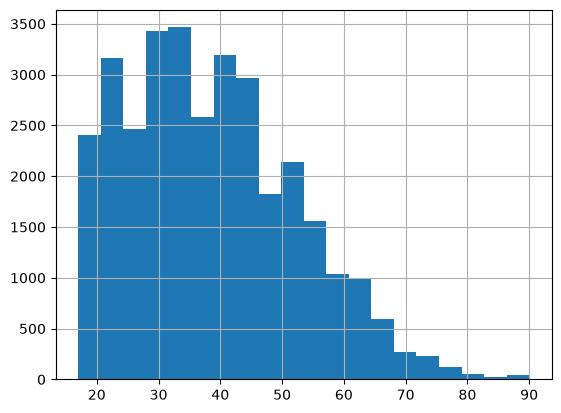

In [18]:
subset['age'].hist(bins=20)

The age that has the most is 30, with the age having the least being 85. It also looks like as age increase the number individuals decreases. 

The next step is to create a function to get rid of whitespace, and use that for the remaining subset variables (education and occupation). 

In [19]:
def strip_whitespace(s):
    return s.strip()

New column values will be added to the dataset and the old column will be dropped. 

In [20]:
# Education
subset['education_stripped'] = UCI['education'].apply(strip_whitespace)
subset['education'] = subset['education_stripped']
subset.drop(labels = ['education_stripped'],axis=1,inplace=True)

# Occupation 
subset['occupation_stripped'] = UCI['occupation'].apply(strip_whitespace)
subset['occupation']  =subset['occupation_stripped']
subset.drop(labels = ['occupation_stripped'],axis=1,inplace=True)

Using the new subset, people between the ages 30 to 50 will be used as a filter. 

In [21]:
UCI_filter = subset[(subset['age']>=30) & (subset['age']<=50)]

UCI_filter.head()

,age,education,occupation
0,39,Bachelors,Adm-clerical
1,50,Bachelors,Exec-managerial
2,38,HS-grad,Handlers-cleaners
5,37,Masters,Exec-managerial
6,49,9th,Other-service


In [22]:
number = UCI_filter.shape[0]

print("There are {} people between 30 to 50".format(number))

There are 16390 people between 30 to 50


Data can then be grouped based on age and education to find mean age. 

In [23]:
subset.groupby(['education'])['age'].mean()

education
10th            37.429796
11th            32.355745
12th            32.000000
1st-4th         46.142857
5th-6th         42.885886
7th-8th         48.445820
9th             41.060311
Assoc-acdm      37.381443
Assoc-voc       38.553546
Bachelors       38.904949
Doctorate       47.702179
HS-grad         38.974479
Masters         44.049913
Preschool       42.764706
Prof-school     44.746528
Some-college    35.756275
Name: age, dtype: float64

This shows the average age of people within each education category. One interesting thing about the mean age for education is that most are above 30. The mean age for 1st-4th grade is 46.14. Someone with a Doctorate has an average age of 47.7. 

The next part is to group by occupation and age. 

In [24]:
subset.groupby('occupation')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
occupation,,,,,,,,
?,1843.0,40.882800,20.336350,17.0,21.0,35.0,61.0,90.0
Adm-clerical,3770.0,36.964456,13.362998,17.0,26.0,35.0,46.0,90.0
Armed-Forces,9.0,30.222222,8.089774,23.0,24.0,29.0,34.0,46.0
Craft-repair,4099.0,39.031471,11.606436,17.0,30.0,38.0,47.0,90.0
Exec-managerial,4066.0,42.169208,11.974548,17.0,33.0,41.0,50.0,90.0
Farming-fishing,994.0,41.211268,15.070283,17.0,29.0,39.0,52.0,90.0
Handlers-cleaners,1370.0,32.165693,12.372635,17.0,23.0,29.0,39.0,90.0
Machine-op-inspct,2002.0,37.715285,12.068266,17.0,28.0,36.0,46.0,90.0
Other-service,3295.0,34.949621,14.521508,17.0,22.0,32.0,45.0,90.0


To find the highest average age, the mean age for all of the occupations can be found and sorted from highest to lowest. 

In [25]:
occ_age = subset.groupby('occupation')['age'].mean()
print(occ_age.sort_values(ascending=False))

occupation
Exec-managerial      42.169208
Priv-house-serv      41.724832
Farming-fishing      41.211268
?                    40.882800
Prof-specialty       40.517633
Transport-moving     40.197871
Craft-repair         39.031471
Protective-serv      38.953775
Machine-op-inspct    37.715285
Sales                37.353973
Tech-support         37.022629
Adm-clerical         36.964456
Other-service        34.949621
Handlers-cleaners    32.165693
Armed-Forces         30.222222
Name: age, dtype: float64


The final step for this activity is to idenitfy any outliers in the data. First we can find where 75% of the data lies. 

In [26]:
percentile = subset['age'].quantile(.75)

print(percentile)

48.0


The age of the 75the percentile is 48 years old. 48 can then be used to see how many people are 48 or older for all occupations. 

In [27]:
above_75 = subset[subset['age'] > percentile]

above_75.groupby('occupation').size()

occupation
?                     706
Adm-clerical          748
Craft-repair          919
Exec-managerial      1165
Farming-fishing       308
Handlers-cleaners     160
Machine-op-inspct     394
Other-service         631
Priv-house-serv        53
Prof-specialty        995
Protective-serv       148
Sales                 845
Tech-support          158
Transport-moving      409
dtype: int64

Exec_managerial had the most with 1165 individuals. Prive house serv had the least with 53 individuals. 

Outlier can then be determined using the 25th and 75th percentile to calculate the IQR. A bar plot can then be created to see were most of the outliers are found. 

In [28]:
Q1 = subset['age'].quantile(0.25)
Q3 = subset['age'].quantile(0.75)

IQR = Q3 - Q1

In [29]:
lower = Q1 - 1.5 * IQR
higher = Q3 + 1.5 * IQR

In [30]:
outlier = subset[(subset['age'] < lower) | (subset['age'] > higher)]

outlier

,age,education,occupation
74,79,Some-college,Prof-specialty
222,90,HS-grad,Other-service
430,80,HS-grad,?
918,81,HS-grad,Exec-managerial
1040,90,HS-grad,Other-service
...,...,...,...
32277,90,HS-grad,Adm-clerical
32367,90,7th-8th,Protective-serv
32459,85,Bachelors,Exec-managerial
32494,82,HS-grad,?


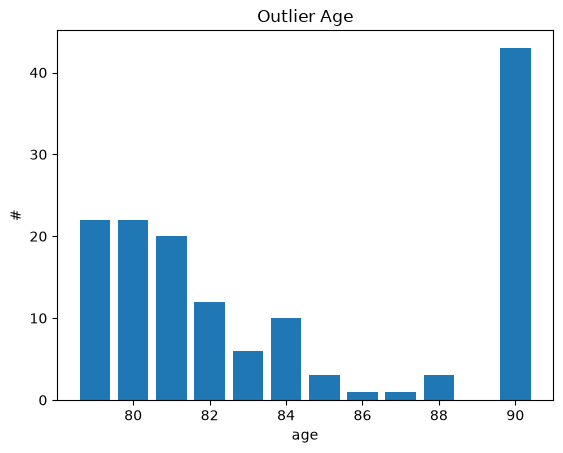

In [31]:
outlier_count = outlier['age'].value_counts().sort_index()

# bar plot creation
plt.bar(outlier_count.index, outlier_count.values)
plt.xlabel('age')
plt.ylabel('#')
plt.title('Outlier Age')
plt.show()

The oultiers are between the ages of 79 to 90, with 90 having the most outliers. 

The final step is to combine the the datasets together. The first one has age, workclass, and occupation. The second one has education and occupation. Occupation is used as the common factor that can be used to connect the two together. 

In [32]:
df1 = UCI[['age', 'workclass', 'occupation']].sample(5, random_state=101)

df2 = UCI[['education', 'occupation']].sample(5, random_state=101)

In [33]:
merged = pd.merge(df1, df2, on='occupation', how='inner').drop_duplicates()

merged

,age,workclass,occupation,education
0,51,Private,Machine-op-inspct,HS-grad
1,19,Private,Sales,11th
2,40,Private,Exec-managerial,HS-grad
3,17,Private,Handlers-cleaners,10th
4,61,Private,Craft-repair,7th-8th


## Activity 3: 
practice basic arithmetic 

A.  Series 1 = 7.3, -2.5, 3.4, 1.5
i. Index = ‘a’, ‘c’, ‘d’, ‘e’

In [3]:
series1 = pd.Series([7.3, -2.5, 3.4, 1.5], index = ['a', 'c', 'd', 'e'])

print(series1)

a    7.3
c   -2.5
d    3.4
e    1.5
dtype: float64


B. Series 2 = -2.1, 3.6, -1.5, 4, 3.1
i. Index = ‘a’, ‘c’, ‘e’, ‘f’, ‘g’

In [5]:
series2 = pd.Series([-2.1, 3.6, -1.5, 4, 3.1], index = ['a', 'c', 'e', 'f', 'g'])
print(series2)

a   -2.1
c    3.6
e   -1.5
f    4.0
g    3.1
dtype: float64


C. Add Series 1 and Series 2 together and print the results

In [6]:
print(series1 + series2)

a    5.2
c    1.1
d    NaN
e    0.0
f    NaN
g    NaN
dtype: float64


D. Subtract Series 1 from Series 2 and print the results. 

In [7]:
print(series1 - series2)

a    9.4
c   -6.1
d    NaN
e    3.0
f    NaN
g    NaN
dtype: float64


In part C and D there are some missing values, this is because series 1 has 4 values and series 2 has 5. Additionally, the indexes do not match, so they cannot be added or subtracted. 